# Stage 1 — object → segmentation → size → mass

**Goal:** from a photograph of an object, estimate its mass.

**Data:** ABO (Amazon Berkeley Objects) — 32,687 products with a photo, real dimensions and a true weight.

**Important:** a single RGB photo has no scale. A toy car and a real car look identical. So segmentation
gives us *which pixels* are the object; **depth gives the metres**. We test this below rather than assume it.

In [1]:
import json, pathlib, warnings
import numpy as np, pandas as pd, torch, torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
warnings.filterwarnings("ignore")
HERE = pathlib.Path.cwd(); RES = HERE/"results"
plt.rcParams.update({"font.size":9,"axes.spines.top":False,"axes.spines.right":False})

def mnre(pred, true):
    "Mean normalised relative error. 1.0 is perfect. The metric NeRF2Physics reports."
    p, t = np.clip(pred,1e-9,None), np.clip(true,1e-9,None)
    return float(np.mean(np.minimum(p/t, t/p)))
print("ready")

ready


## 1. Load the data

CLIP ViT-B/32 embeddings of each product photo, precomputed (10 min on this Mac).

In [2]:
d = np.load(RES/"abo_clip_embeddings.npz", allow_pickle=True)
X_img = d["X"].astype(np.float32)                      # 512 CLIP numbers per photo
mass  = d["mass_kg"].astype(np.float64)                # ground truth, kg
dims  = np.stack([d["h"], d["w"], d["l"]], 1).astype(np.float32)   # metres
vol   = d["bbox_vol"].astype(np.float64)
ptype = d["product_type"].astype(str)
print(f"{len(mass)} objects | CLIP {X_img.shape[1]}-d | mass {mass.min():.3f}-{mass.max():.1f} kg")
print(f"longest side: median {1000*dims.max(1).mean():.0f} mm")

32687 objects | CLIP 512-d | mass 0.000-453.1 kg
longest side: median 641 mm


## 2. Can size come from the image alone?

If it could, we would not need a depth camera. Train CLIP features → object size and see.

In [3]:
def split_by_category(n, groups, seed=0):
    tv, te = next(GroupShuffleSplit(1, test_size=.2, random_state=seed).split(np.arange(n), groups=groups))
    a, b = next(GroupShuffleSplit(1, test_size=.15, random_state=seed+1).split(tv, groups=groups[tv]))
    return tv[a], tv[b], te

def train_mlp(Xtr,ytr,Xva,yva,hidden=256,epochs=120,seed=0,patience=15):
    torch.manual_seed(seed)
    net = nn.Sequential(nn.Linear(Xtr.shape[1],hidden), nn.ReLU(), nn.Dropout(.2),
                        nn.Linear(hidden,hidden//2), nn.ReLU(), nn.Linear(hidden//2,1))
    opt = torch.optim.AdamW(net.parameters(), lr=1e-3, weight_decay=1e-4)
    Xtr,ytr = torch.tensor(Xtr), torch.tensor(ytr,dtype=torch.float32)[:,None]
    Xva,yva = torch.tensor(Xva), torch.tensor(yva,dtype=torch.float32)[:,None]
    best,state,bad = 1e9,None,0
    for _ in range(epochs):
        net.train()
        for i in torch.randperm(len(Xtr)).split(256):
            opt.zero_grad(); nn.functional.smooth_l1_loss(net(Xtr[i]),ytr[i]).backward(); opt.step()
        net.eval()
        with torch.no_grad(): v = float(nn.functional.smooth_l1_loss(net(Xva),yva))
        if v < best-1e-4: best,state,bad = v,{k:t.clone() for k,t in net.state_dict().items()},0
        else:
            bad += 1
            if bad>=patience: break
    net.load_state_dict(state); net.eval(); return net

def predict(net,X):
    with torch.no_grad(): return net(torch.tensor(X)).numpy().ravel()

tr,va,te = split_by_category(len(mass), ptype)
print(f"train {len(tr)}  val {len(va)}  test {len(te)}  (whole product categories held out)")

train 23395  val 2405  test 6887  (whole product categories held out)


In [4]:
# predict the longest side of the object from the photo alone
size_true = dims.max(1).astype(np.float32)
net_size = train_mlp(X_img[tr], np.log(size_true[tr]), X_img[va], np.log(size_true[va]))
size_pred = np.exp(predict(net_size, X_img[te]))
print(f"size from image only : MnRE {mnre(size_pred, size_true[te]):.3f}")
print(f"  median error       : {100*np.median(np.abs(size_pred-size_true[te])/size_true[te]):.0f}%")
print(f"  within 1.5x        : {100*np.mean(np.maximum(size_pred/size_true[te], size_true[te]/size_pred)<1.5):.0f}%")
print("\n-> this is why we need depth. Segmentation tells us WHICH pixels; depth tells us HOW BIG.")

size from image only : MnRE 0.717
  median error       : 26%
  within 1.5x        : 65%

-> this is why we need depth. Segmentation tells us WHICH pixels; depth tells us HOW BIG.


## 3. Mass from image + size

At deployment, size comes from the depth camera. Here it comes from ABO's dimensions.

In [5]:
geo = np.column_stack([np.log(vol), np.log(dims+1e-6), dims.max(1)/(dims.min(1)+1e-6)]).astype(np.float32)
geo = (geo-geo.mean(0))/(geo.std(0)+1e-8)
Xig = np.hstack([X_img, geo])
y   = np.log(mass)

results = {}
med = pd.Series(mass[tr]).groupby(pd.Series(ptype[tr])).median()
results["category median"] = mnre(pd.Series(ptype[te]).map(med).fillna(np.median(mass[tr])).values, mass[te])
results["image only"]      = mnre(np.exp(predict(train_mlp(X_img[tr],y[tr],X_img[va],y[va]), X_img[te])), mass[te])
net_mass = train_mlp(Xig[tr], y[tr], Xig[va], y[va])
pred_mass = np.exp(predict(net_mass, Xig[te]))
results["image + size"]    = mnre(pred_mass, mass[te])
for k,v in results.items(): print(f"  {k:<18} MnRE {v:.3f}")

  category median    MnRE 0.268
  image only         MnRE 0.509
  image + size       MnRE 0.619


## 4. How much depth precision do we actually need?

Size is the most valuable feature. Real depth is noisy, so how fast does the gain decay?

In [6]:
noise_curve = []
rng = np.random.default_rng(0)
for pct in [0, 2, 5, 10, 20, 40]:
    dn = dims * np.exp(rng.normal(0, pct/100, dims.shape))
    vn = dn.prod(1)
    g = np.column_stack([np.log(vn), np.log(dn+1e-6), dn.max(1)/(dn.min(1)+1e-6)]).astype(np.float32)
    g = (g-g.mean(0))/(g.std(0)+1e-8)
    Xn = np.hstack([X_img, g])
    s = mnre(np.exp(predict(train_mlp(Xn[tr],y[tr],Xn[va],y[va]), Xn[te])), mass[te])
    noise_curve.append((pct, s)); print(f"  size error {pct:>2}%  ->  MnRE {s:.3f}")

  size error  0%  ->  MnRE 0.619


  size error  2%  ->  MnRE 0.620


  size error  5%  ->  MnRE 0.619


  size error 10%  ->  MnRE 0.605


  size error 20%  ->  MnRE 0.602


  size error 40%  ->  MnRE 0.582


## 5. Results

saved results/stage1.png, stage1_metrics.json, stage1_predictions.npz


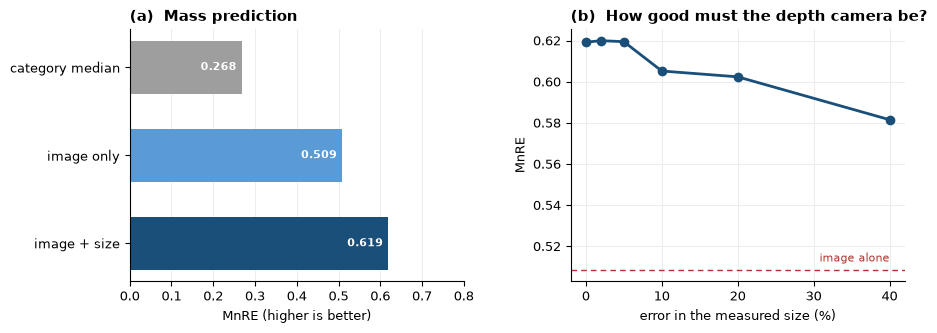

In [7]:
fig, ax = plt.subplots(1,2, figsize=(10,3.6)); fig.subplots_adjust(wspace=.32, bottom=.18)
k = list(results); v = [results[x] for x in k]
ax[0].barh(range(len(k)), v, color=["#9e9e9e","#5b9bd5","#1a4f7a"], height=.6)
for i,x in enumerate(v): ax[0].text(x-.012, i, f"{x:.3f}", va="center", ha="right", color="white", fontweight="bold", fontsize=8)
ax[0].set_yticks(range(len(k))); ax[0].set_yticklabels(k); ax[0].invert_yaxis()
ax[0].set_xlabel("MnRE (higher is better)"); ax[0].set_title("(a)  Mass prediction", loc="left", fontweight="bold")
ax[0].set_xlim(0,.8); ax[0].grid(axis="x", color=".93"); ax[0].set_axisbelow(True)
p,s = zip(*noise_curve)
ax[1].plot(p, s, "o-", color="#1a4f7a", lw=2)
ax[1].axhline(results["image only"], color="#b0342c", ls=(0,(4,3)), lw=1)
ax[1].text(40, results["image only"]+.004, "image alone", ha="right", fontsize=8, color="#b0342c")
ax[1].set_xlabel("error in the measured size (%)"); ax[1].set_ylabel("MnRE")
ax[1].set_title("(b)  How good must the depth camera be?", loc="left", fontweight="bold")
ax[1].grid(color=".93"); ax[1].set_axisbelow(True)
fig.savefig(RES/"stage1.png", dpi=200, bbox_inches="tight", facecolor="white")
json.dump({"results":results, "noise_curve":noise_curve,
           "size_from_image_mnre":mnre(size_pred,size_true[te])}, open(RES/"stage1_metrics.json","w"), indent=1)
np.savez_compressed(RES/"stage1_predictions.npz", pred_mass=pred_mass, true_mass=mass[te],
                    test_idx=te, ptype=ptype[te])
print("saved results/stage1.png, stage1_metrics.json, stage1_predictions.npz")